In [1]:
from functions.clustering_functions import clustering_2_communities, ARI_fscore
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science'])
from functions.plots import plot_ARI_f1
from functions.main_functions import load_presaved_data, normal_run, run_squic_fit, run_squic_fit_matrix, ask_yes_no, ask_input
from functions.cosmograph_functions import visualize_graph_paysim

First pass: Identifying users and fraud accounts...
Found 1026 unique users
Found 183 fraud accounts
Second pass: Processing transactions and building matrices...


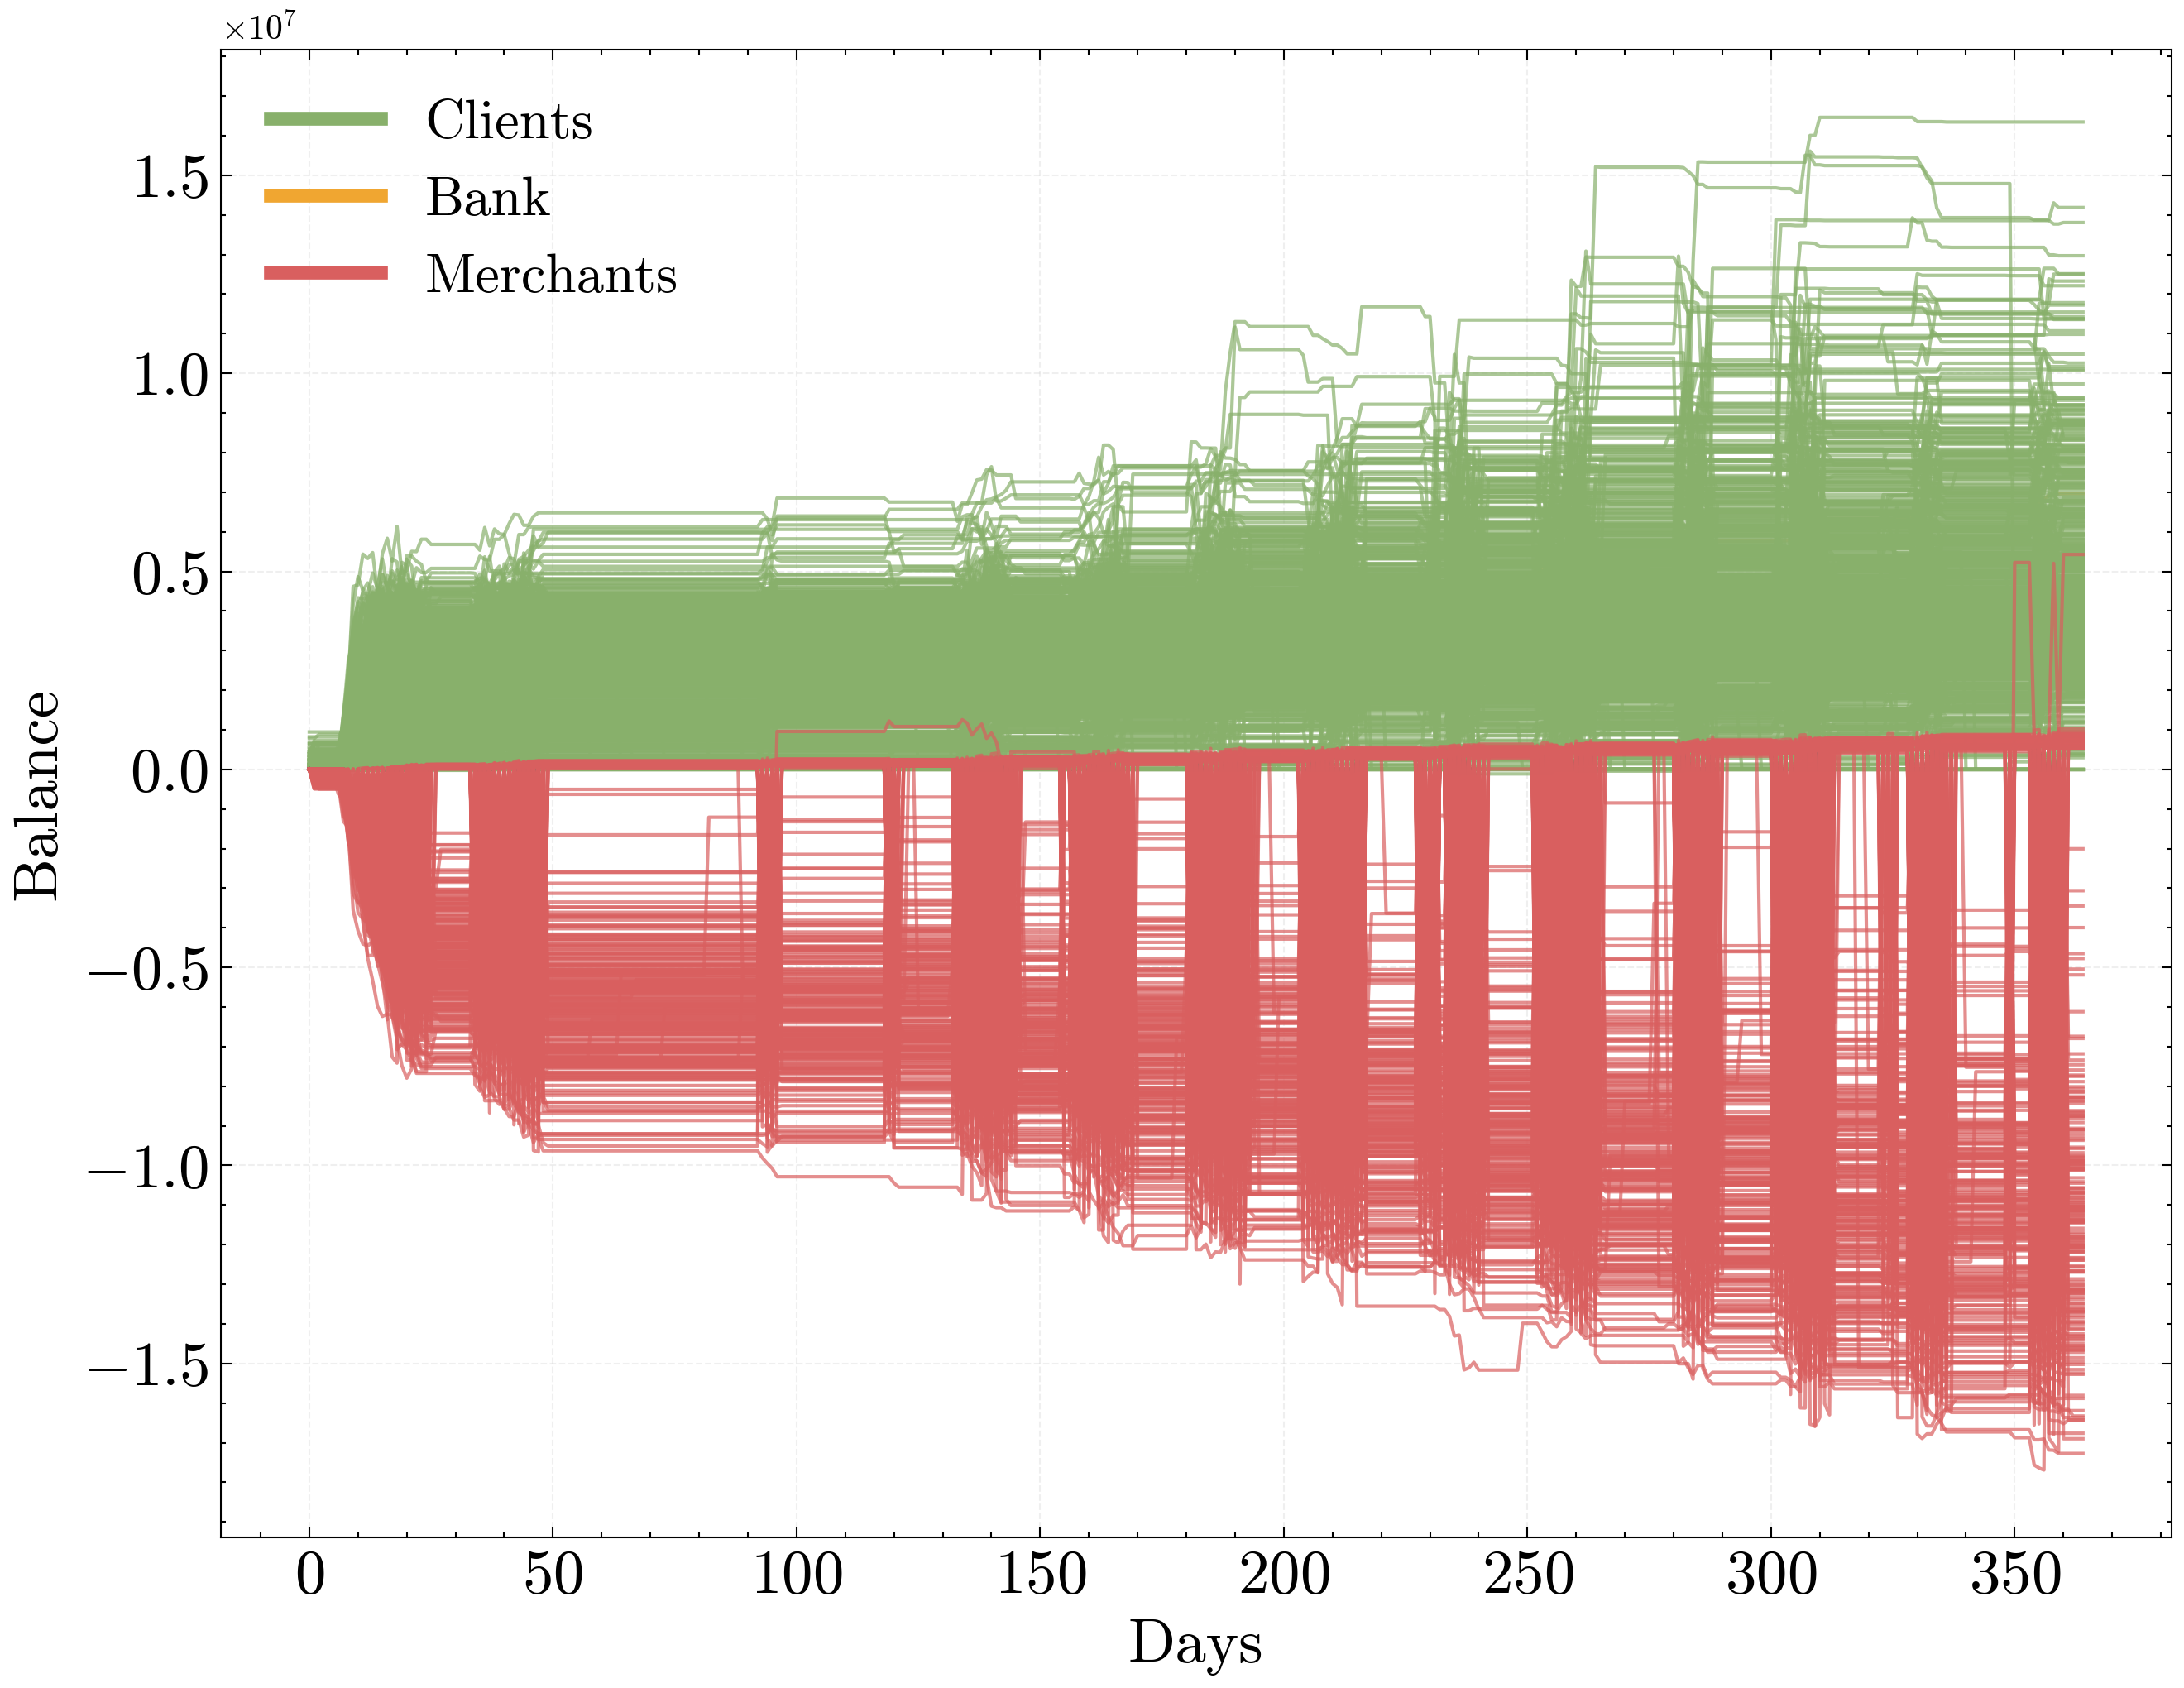

     B5850430173  C0001731763  C0003913541  C0020644673  C0044341273  \
0           0.00     14693.17        59.89        57.04        39.89   
1           0.00     14693.17        59.89        57.04        39.89   
2           0.00     14693.17    132112.55        57.04        39.89   
3           0.00     14693.17    132112.55        57.04        39.89   
4           0.00     14693.17    132112.55        57.04        39.89   
..           ...          ...          ...          ...          ...   
360   6964088.80   6575822.91   4679954.66         0.00   3783931.27   
361   6967246.68   6575822.91   4679954.66         0.00   3783931.27   
362   6967246.68   6575822.91   4679954.66         0.00   3783931.27   
363   6967246.68   6575822.91   4679954.66         0.00   3783931.27   
364   6967246.68   6575822.91   4679954.66         0.00   3783931.27   

     C0086812805  C0121278517  C0124661383  C0128381386  C0147974956  ...  \
0          76.68         3.70       377.39         58.0   

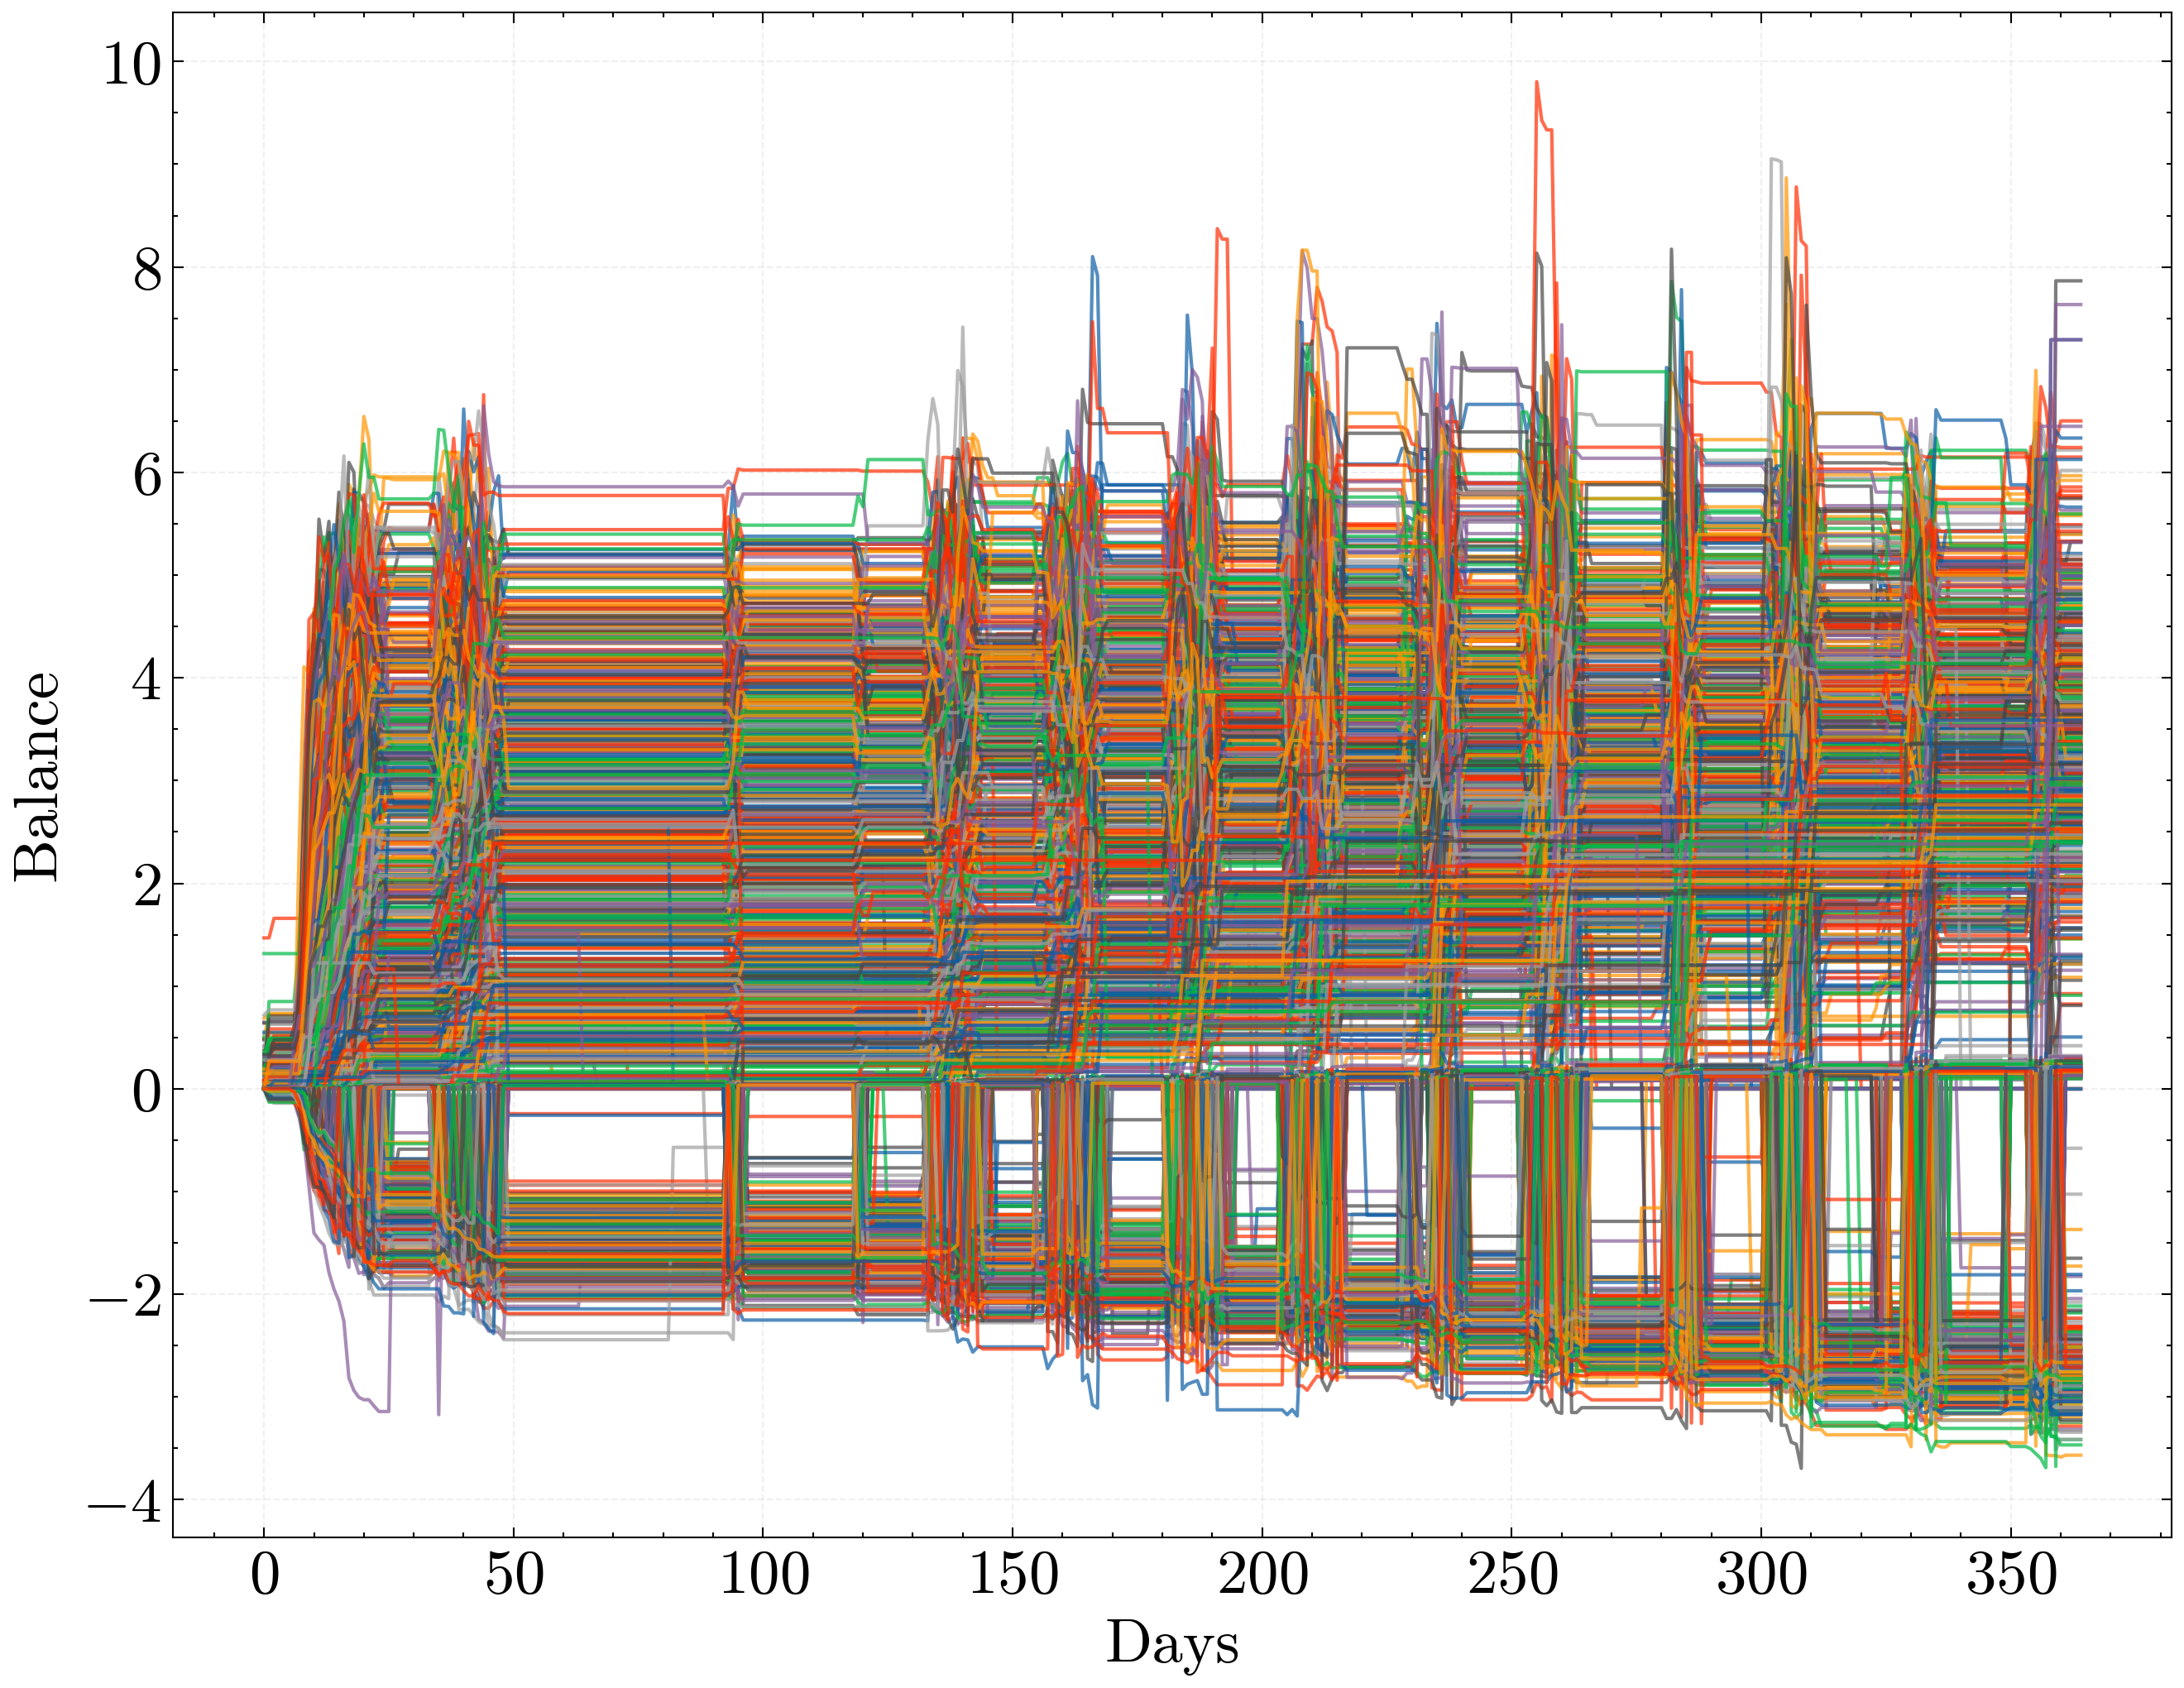

           0         1         2         3         4         5         6    \
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1     0.006122  0.006122  0.006122  0.006122  0.006122  0.006122  0.006122   
2     0.000026  0.000026  0.057122  0.057122  0.057122  0.057122  0.057122   
3     0.000020  0.000020  0.000020  0.000020  0.000020  0.000020  0.000020   
4     0.000053  0.000053  0.000053  0.000053  0.000053  0.000053  0.000053   
...        ...       ...       ...       ...       ...       ...       ...   
1021  0.000000  0.000000 -0.059129 -0.059129 -0.059129 -0.059129 -0.059129   
1022  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1023  0.000000 -0.026779 -0.026779 -0.026779 -0.026779 -0.026779 -0.026779   
1024  0.000000 -0.022486 -0.022486 -0.022486 -0.022486 -0.022486 -0.022486   
1025  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000 -0.026041   

           7         8         9    ...       355       356    

In [ ]:
user_input = ask_yes_no("\nDo you want to load data?")

name = 'PAYSIM'
if user_input == 'Y':
    Y_norm, knn_matrix, account_prop, dimension = load_presaved_data(name)
    
else: # Normal run
    Y_norm, knn_matrix, account_prop, dimension = normal_run(name)
    
results_squic = {}
# Run SQUIC_fit
if ask_yes_no("SQUIC-Fit with bias or no?") == 'Y':
    results_squic, squic_method, save = run_squic_fit_matrix(Y_norm, knn_matrix, results_squic, name, dimension)
    
else:
    results_squic, squic_method, save = run_squic_fit(Y_norm, results_squic, name, dimension)


for rho 0.6 graph is connected: False
Computing spectral clustering for rho 0.6...
For rho 0.6 takes 0.0 seconds

for rho 0.5 graph is connected: False
Computing spectral clustering for rho 0.5...
For rho 0.5 takes 0.0 seconds

for rho 0.4 graph is connected: False
Computing spectral clustering for rho 0.4...
For rho 0.4 takes 0.0 seconds

for rho 0.3 graph is connected: False
Computing spectral clustering for rho 0.3...
For rho 0.3 takes 0.0 seconds

for rho 0.2 graph is connected: True
Computing spectral clustering for rho 0.2...
For rho 0.2 takes 0.0 seconds

for rho 0.1 graph is connected: True
Computing spectral clustering for rho 0.1...
For rho 0.1 takes 0.0 seconds
for rho = 0.6 : {'Spectral': {'nCluster': 2, 'ARI': 0.01, 'f1': 0.55}}
for rho = 0.5 : {'Spectral': {'nCluster': 2, 'ARI': 1.0, 'f1': 1.0}}
for rho = 0.4 : {'Spectral': {'nCluster': 2, 'ARI': 1.0, 'f1': 1.0}}
for rho = 0.3 : {'Spectral': {'nCluster': 2, 'ARI': 0.93, 'f1': 0.99}}
for rho = 0.2 : {'Spectral': {'nCluste

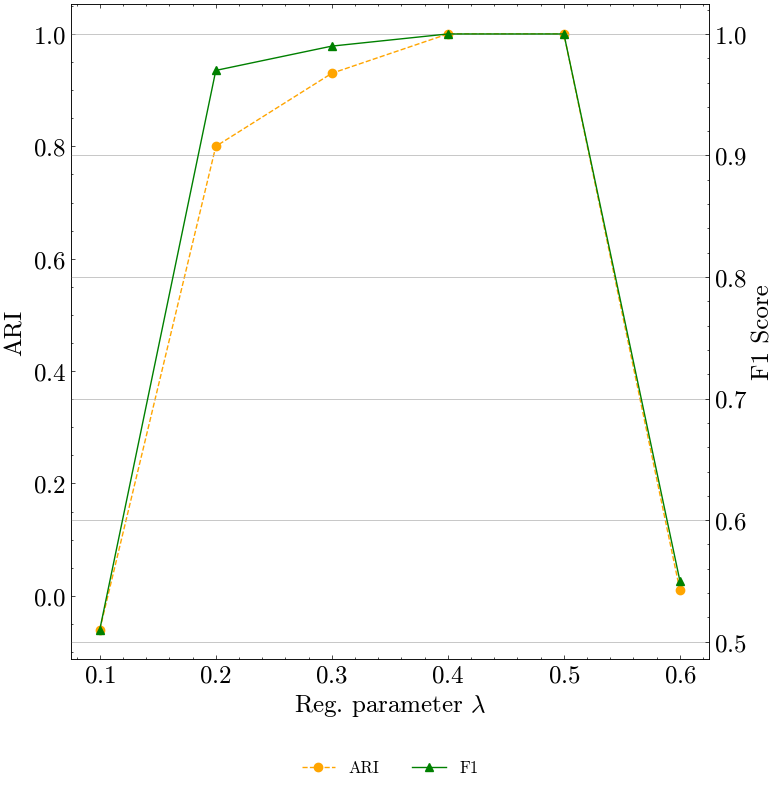

In [3]:
# Results
dict_cluster = clustering_2_communities(results_squic, squic_method, dimension)

metrics = ARI_fscore(dict_cluster, results_squic, account_prop)

for _, data in metrics.items():
    for rho, results in data.items():
        print(f"for rho = {rho} : {results}")

plot_ARI_f1(metrics, squic_method, dimension, save)

In [4]:
lambda_graph = {
    '100': 0.2,
    '1K': 0.8,
    '10K': 0.997,
    '100K': 0.99991
}

In [5]:
graph = visualize_graph_paysim(results_squic, squic_method, dict_cluster, account_prop, show_label=True, export=lambda_graph.get(dimension))

Exported for Cosmograph WebApp: cosmograph_export/PAYSIM_0.2_edges.csv and _nodes.csv


In [6]:
graph.get(lambda_graph.get(dimension))

Cosmograph(background_color='#FFFFFF', focused_point_ring_color=None, hovered_point_ring_color=None, link_colo…